# Gridded Mooring Data - Quick Plot

From an erddap Dataset, specify the Mooring ID to get a quick plot of the data

In [39]:
from erddapy import ERDDAP
import xarray as xa
import numpy as np

In [40]:
import cmocean
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.dates import YearLocator, WeekdayLocator, MonthLocator, DayLocator, HourLocator, DateFormatter
import matplotlib.ticker as ticker

#wrap the plot in image settings for visual appeal
# may be able to make this cleaner or just a preset
%run '../../settings/mpl_plot_settings.py'


<Figure size 640x480 with 0 Axes>

In [41]:
server_url = 'http://ecofoci-field.pmel.noaa.gov:8081/erddap'
dataset_name = '1hr_gridded_datasets_Mooring_25bs2a_final'

xdf = xa.load_dataset(f'{server_url}/griddap/{dataset_name}')

/Users/bell/mambaforge/envs/p312/lib/python3.12/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'temperature' has multiple fill values {np.float64(1e+35), np.float64(-9999.0)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/Users/bell/mambaforge/envs/p312/lib/python3.12/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'pressure' has multiple fill values {np.float64(1e+35), np.float64(-9999.0)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/Users/bell/mambaforge/envs/p312/lib/python3.12/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'salinity' has multiple fill values {np.float64(1e+35), np.float64(-9999.0)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/Users/bell/mambaforge/envs/p312/lib/python3.12/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'par' has multiple fill values {np.float64(1e+35), np.float64(-9

In [42]:
server_url = 'http://ecofoci-field.pmel.noaa.gov:8081/erddap'
dataset_name = '1hr_gridded_datasets_Mooring_25bspr2a_final'
e = ERDDAP(server=server_url,
          protocol='griddap',
          response='ncCF')

e.dataset_id=dataset_name

pdf = xa.load_dataset(f'{server_url}/griddap/{dataset_name}')

/Users/bell/mambaforge/envs/p312/lib/python3.12/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'temperature' has multiple fill values {np.float64(1e+35), np.float64(-9999.0)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/Users/bell/mambaforge/envs/p312/lib/python3.12/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'pressure' has multiple fill values {np.float64(1e+35), np.float64(-9999.0)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/Users/bell/mambaforge/envs/p312/lib/python3.12/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'salinity' has multiple fill values {np.float64(1e+35), np.float64(-9999.0)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/Users/bell/mambaforge/envs/p312/lib/python3.12/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'par' has multiple fill values {np.float64(1e+35), np.float64(-9

In [43]:
xdf.depth.values

array([10., 12., 17., 21., 23., 25., 29., 33., 38., 43., 45., 48., 53.,
       58., 63.])

In [44]:
ydf = xa.Dataset(coords={'depth':np.arange(0,72,1),'time':xdf.time,})
ydf

<xarray.Dataset> Size: 24kB
Dimensions:  (time: 2947, depth: 72)
Coordinates:
  * time     (time) datetime64[ns] 24kB 2025-04-30T04:00:00 ... 2025-08-30T22...
  * depth    (depth) int64 576B 0 1 2 3 4 5 6 7 8 ... 63 64 65 66 67 68 69 70 71
Data variables:
    *empty*

In [45]:
ydf = ydf.merge(xdf)
ydf = ydf.merge(pdf)

/var/folders/6r/n_mpcj7d7pdf9ncqvjy5vb8c0000jm/T/ipykernel_65634/390409114.py:1: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'depth' ('depth',) The recommendation is to set join explicitly for this case.
  ydf = ydf.merge(xdf)
/var/folders/6r/n_mpcj7d7pdf9ncqvjy5vb8c0000jm/T/ipykernel_65634/390409114.py:2: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'time' ('time',) The recommendation is to set join explicitly for this case.
  ydf = ydf.merge(pdf)
/var/folders/6r/n_mpcj7d7pdf9ncqvjy5vb8c0000jm/T/ipykernel_656

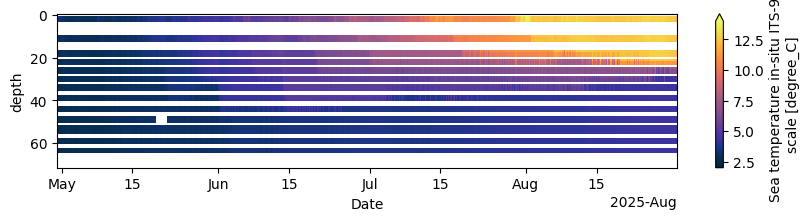

In [46]:
upper_temp = ydf.temperature.max(axis=0).max(axis=0).values
lower_temp = 2

fig, ax = plt.subplots(1,figsize=(10, 2))
ydf.temperature.interpolate_na('depth',limit=1).ffill('depth',1).plot(ax=ax,yincrease=False,vmin=lower_temp,vmax=14,cmap=cmocean.cm.thermal)

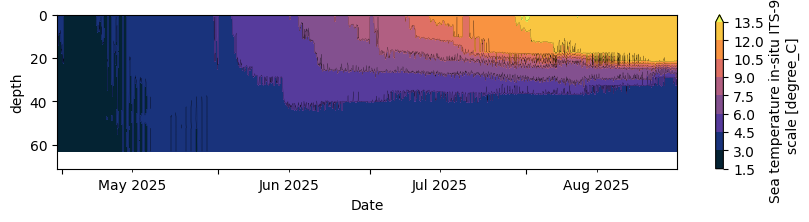

In [47]:
fig, ax = plt.subplots(1,figsize=(10, 2))
ydf.temperature.interpolate_na('depth').plot.contourf(ax=ax,levels=10,yincrease=False,robust=True,cmap=cmocean.cm.thermal)
ydf.temperature.interpolate_na('depth').plot.contour(ax=ax,levels=10,yincrease=False,robust=True,colors='k',linewidths=.125)

# xfmt = mdates.DateFormatter('%d-%b')
ax.xaxis.set_major_locator(DayLocator(bymonthday=1))
ax.xaxis.set_minor_locator(DayLocator(bymonthday=15))
ax.xaxis.set_minor_formatter(DateFormatter('%b %Y'))
ax.xaxis.set_major_formatter(DateFormatter(''))
ax.xaxis.set_tick_params(which='major', pad=3)
ax.xaxis.set_tick_params(which='minor', pad=5)

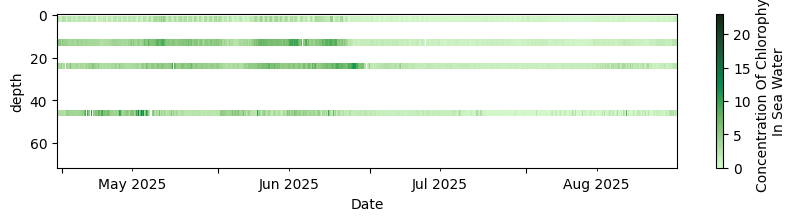

In [48]:
upper_temp = xdf.chlorophyll_fluorescence.max(axis=0).max(axis=0).values
lower_temp = 0

fig, ax = plt.subplots(1,figsize=(10, 2))
ydf.chlorophyll_fluorescence.interpolate_na('depth',limit=0).ffill('depth',2).plot(ax=ax,yincrease=False,vmin=lower_temp,vmax=upper_temp,cmap=cmocean.cm.algae)


# xfmt = mdates.DateFormatter('%d-%b')
ax.xaxis.set_major_locator(DayLocator(bymonthday=1))
ax.xaxis.set_minor_locator(DayLocator(bymonthday=15))
ax.xaxis.set_minor_formatter(DateFormatter('%b %Y'))
ax.xaxis.set_major_formatter(DateFormatter(''))
ax.xaxis.set_tick_params(which='major', pad=3)
ax.xaxis.set_tick_params(which='minor', pad=5)

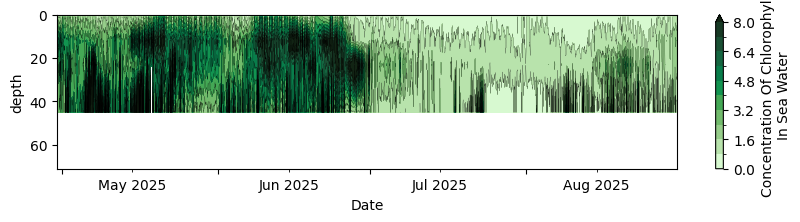

In [49]:
fig, ax = plt.subplots(1,figsize=(10, 2))
ydf.chlorophyll_fluorescence.interpolate_na('depth').plot.contourf(ax=ax,levels=10,yincrease=False,robust=True,cmap=cmocean.cm.algae)
ydf.chlorophyll_fluorescence.interpolate_na('depth').plot.contour(ax=ax,levels=10,yincrease=False,robust=True,colors='k',linewidths=.125)

# xfmt = mdates.DateFormatter('%d-%b')
ax.xaxis.set_major_locator(DayLocator(bymonthday=1))
ax.xaxis.set_minor_locator(DayLocator(bymonthday=15))
ax.xaxis.set_minor_formatter(DateFormatter('%b %Y'))
ax.xaxis.set_major_formatter(DateFormatter(''))
ax.xaxis.set_tick_params(which='major', pad=3)
ax.xaxis.set_tick_params(which='minor', pad=5)

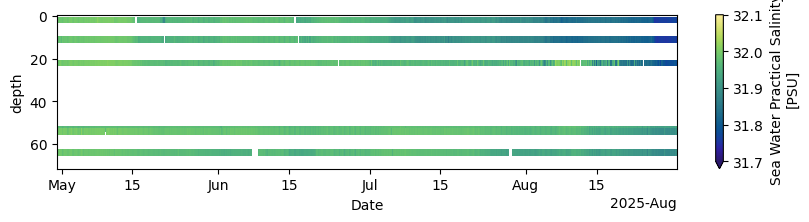

In [50]:
upper_temp = 32.1
lower_temp = 31.7

fig, ax = plt.subplots(1,figsize=(10, 2))
ydf.salinity.interpolate_na('depth',limit=0).ffill('depth',2).plot(ax=ax,
                                                                   yincrease=False,
                                                                   vmin=lower_temp,
                                                                   vmax=upper_temp,cmap=cmocean.cm.haline)

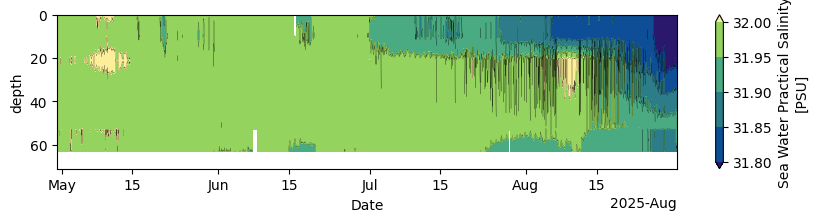

In [51]:
fig, ax = plt.subplots(1,figsize=(10, 2))
ydf.salinity.interpolate_na('depth').plot.contourf(ax=ax,levels=5,yincrease=False,robust=True,cmap=cmocean.cm.haline)
ydf.salinity.interpolate_na('depth').plot.contour(ax=ax,levels=5,yincrease=False,robust=True,colors='k',linewidths=.125)

## Export to CSV - via pandas

In [52]:
variable = 'temperature'

for g, group in xdf[variable].dropna(dim='depth',how='all').groupby('depth'):
    group.to_dataframe().to_csv(f'{dataset_name}_{variable}.{g}m.csv')

## Perform 35hr Lanzcos Filter and export data

A common filter to apply to the hourly data is a 35hr Lanzcos Lowpass filter

In [53]:
import EcoFOCIpy.math.lanzcos as lanzcos #<- instrument specific
import matplotlib.pyplot as plt


In [54]:
for g, group in xdf[variable].dropna(dim='depth',how='all').groupby('depth'):
    dft = group.to_dataframe().dropna()
    #
    ## missing data fill limited by number of hours to linearly interpolate
    temp = dft[variable].interpolate(method='time',limit=6)

    # get index of missing data that wasn't filled
    # the remaining missing data will continue to be missing after analysis
    # this data and the edges of the timeseries need to have the effects of the filter window accounted for

    missing_index = np.isnan(temp)
    temp = dft[variable].interpolate(method='time')

    #address gaps at beginning and end... back fill... and forward fill at end... 
    # the filter window will correct small gaps at the tails but will become worse as the leading gaps get bigger
    temp.bfill(inplace=True)
    temp.ffill(inplace=True)

    #filter data with lanzcos filter
    lanzcosfiltered = lanzcos.lanzcos(temp.values,1,35) + dft[variable].mean()
    
    fig, axes = plt.subplots(nrows=1, ncols=1,figsize=(4,1), sharex=True)
    temp.plot(ax=axes)
    (temp *0 + lanzcosfiltered).plot(ax=axes)
    
    (temp *0 + lanzcosfiltered).to_csv(f'{dataset_name}_{variable}_35hr.{g}m.csv')

ValueError: Only `method=linear` interpolation is supported on MultiIndexes.

## Make a bottom dataset

In [ ]:
xdf.sel({'depth':slice(46,55)}).mean({'depth'}).temperature.to_dataframe().to_csv(f'{dataset_name}_{variable}.bottom.csv')